# 실습 2 · 파트 3 — 시간을 잇는 호모그래피, "Dear Photograph"

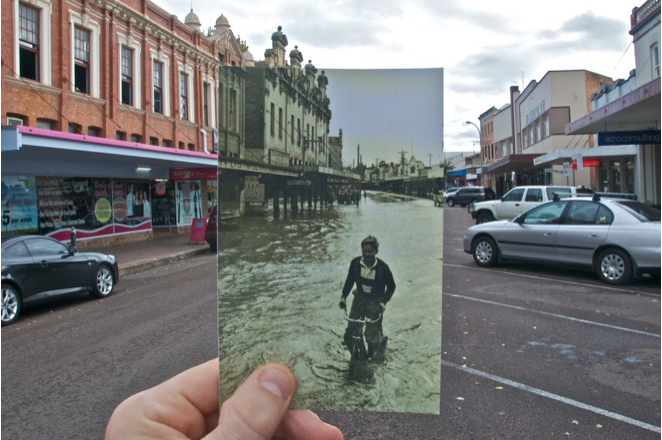

**수십 년 전 본관 사진을 오늘의 정면 사진 위에 정합해 붙인다**

| 노트북 | 내용 |
|---|---|
| 파트 1 | 내 카메라 캘리브레이션 — 촬영 규칙 · 보드 촬영 · K와 σ 확인 |
| 파트 2 | 매칭 `빈칸 ①` · 호모그래피 DLT `빈칸 ②` · RANSAC · 워핑 · 블렌딩 `빈칸 ③` → 내 파노라마 |
| **파트 3** | **시간 정합** — 자동 매칭의 실패 · 클릭 대응 15점 → 내 DLT → 4가지 합성 |

같은 파사드 평면이니 **호모그래피 한 장**이면 충분합니다 — 파트 2에서 만든 `estimate_H_dlt`를
사진이 아니라 **시간**을 잇는 데 그대로 재사용합니다.

이 노트북은 **단독 실행 가능**합니다. 파노라마 파이프라인이 필요 없고, 아래 `셀 1`이
매칭기(SIFT/BF)와 정규화 DLT만 준비합니다. 파트 2에서 **직접 채운 `build_A_rows`** 가 있다면
셀 1의 `from solutions import ...` 에서 그 이름을 빼고 자기 함수를 붙여넣으세요.

In [ ]:
# ── 셀 1 · 환경 준비 (+ 매칭기 · 내 DLT) ─────────────────────────
import cv2, json, math, time, os, glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps

import matplotlib.font_manager as fm
for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
             'Noto Sans CJK KR', 'Noto Sans CJK JP', 'Noto Sans KR']:
    if any(cand == f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = cand; break
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('.'); OUT = BASE / 'out'; OUT.mkdir(exist_ok=True)

def load_image(path, max_side=None):
    # EXIF 회전을 반영해 로드 → BGR, 필요 시 축소
    im = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    img = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)
    if max_side and max(img.shape[:2]) > max_side:
        s = max_side / max(img.shape[:2])
        img = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return img

def show(img, title='', figsize=(9, 5.4)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(title); plt.axis('off'); plt.show()

# 빈칸 ①②의 값·함수 (파트 2~3에서 직접 채운 것이 있으면 여기에 붙여넣으세요)
from solutions import DEFAULT_RATIO as RATIO, build_A_rows

try:
    FEAT = cv2.SIFT_create(nfeatures=4000); NORM = cv2.NORM_L2
except AttributeError:
    FEAT = cv2.ORB_create(nfeatures=4000); NORM = cv2.NORM_HAMMING
    print('SIFT 불가 → ORB 대체')
bf = cv2.BFMatcher(NORM)

def _normalize(pts):
    """무게중심 → 원점, 평균 거리 → √2 (Hartley). 반환: 정규화 좌표, 변환 T"""
    c = pts.mean(axis=0); d = np.linalg.norm(pts - c, axis=1).mean()
    s = math.sqrt(2) / max(d, 1e-12)
    T = np.array([[s, 0, -s * c[0]], [0, s, -s * c[1]], [0, 0, 1]])
    ph = np.hstack([pts, np.ones((len(pts), 1))]) @ T.T
    return ph[:, :2], T

def estimate_H_dlt(src, dst):
    """정규화 DLT: src→dst 호모그래피 (파트 3에서 만든 그 함수)"""
    sn, Ts = _normalize(np.asarray(src, float)); dn, Td = _normalize(np.asarray(dst, float))
    A = []
    for (x, y), (xp, yp) in zip(sn, dn):
        r1, r2 = build_A_rows(x, y, xp, yp); A += [r1, r2]
    _, _, Vt = np.linalg.svd(np.asarray(A)); Hn = Vt[-1].reshape(3, 3)
    H = np.linalg.inv(Td) @ Hn @ Ts
    return H / H[2, 2]

print('OpenCV', cv2.__version__, '| RATIO', RATIO, '| estimate_H_dlt 준비 완료')

---
## 먼저 · 자동 매칭은 왜 실패하는가

시점까지 거의 같은 정면 사진인데도 SIFT + ratio test는 대응을 거의 못 찾습니다.
**왜 안 되는지부터** 확인하고, 그다음 사람이 클릭으로 대응을 공급합니다.

In [ ]:
# ── 셀 B1 · 자동 매칭은 왜 실패하는가 ───────────────────────────
tw_old = load_image(BASE / 'data' / 'timewarp' / 'hyu_old.jpg')
tw_new = load_image(BASE / 'data' / 'timewarp' / 'hyu_modern.jpg')
Ho_, Wo_ = tw_old.shape[:2]; Hn_, Wn_ = tw_new.shape[:2]
show(np.hstack([cv2.resize(tw_old, (int(Wo_*420/Ho_), 420)),
                np.full((420, 16, 3), 255, np.uint8),
                cv2.resize(tw_new, (int(Wn_*420/Hn_), 420))]),
     '왼쪽: 과거 (필름) · 오른쪽: 현재 — 시점까지 거의 같은 정면', (12, 4.2))

g1, g2 = [cv2.cvtColor(x, cv2.COLOR_BGR2GRAY) for x in (tw_old, tw_new)]
k1, d1 = FEAT.detectAndCompute(g1, None); k2, d2 = FEAT.detectAndCompute(g2, None)
raw = bf.knnMatch(d1, d2, k=2)
good = [m for m, n in raw if m.distance < RATIO * n.distance]
n_inl = 0
if len(good) >= 8:
    s = np.float32([k1[m.queryIdx].pt for m in good]); t = np.float32([k2[m.trainIdx].pt for m in good])
    Ht, msk = cv2.findHomography(s, t, cv2.RANSAC, 4.0)
    n_inl = int(msk.sum()) if msk is not None else 0
print(f'자동: 매칭 {len(good)}개 → 인라이어 {n_inl}개 — 사실상 실패')
print('시점이 같아도 실패 → 원인은 시점이 아니라 필름↔디지털의 외관 격차.')
print('구조(기둥·페디먼트)는 그대로다 — 사람의 대응 능력이 필요한 순간 (실습 3의 예고편)')

### 확대 클릭 툴 → JSON → 내 DLT

패키지의 **`corr_picker.html`** 을 브라우저로 여세요.

1. 두 이미지가 자동 로드됩니다 (안 보이면 상단 파일 선택으로 `data/timewarp/`의 두 장을 지정)
2. 자유롭게 15개 이상 대응 점을 클릭
   각 랜드마크마다 [과거 → 현재] 클릭 · **휠 확대 + 드래그 이동**으로 정밀하게 · `Z` 되돌리기
3. `JSON 내보내기` → 받은 파일을 **`my_corr/timewarp_corr.json`** 으로 저장

아직 안 찍었다면 강사 예시(`corr_default.json`)로 우선 진행됩니다.

In [ ]:
# ── 셀 B2 · 클릭 JSON 읽기 → 내 DLT → 4가지 합성 ────────────────
corr_path = BASE / 'my_corr' / 'timewarp_corr.json'
if not corr_path.exists():
    corr_path = BASE / 'data' / 'timewarp' / 'corr_default.json'
    print('⚠ my_corr/timewarp_corr.json 없음 — 강사 예시 대응으로 임시 진행 (툴로 직접 찍어 보세요)')
tw = json.load(open(corr_path, encoding='utf-8'))
tw_src = np.float64([p['old'] for p in tw['points']])
tw_dst = np.float64([p['new'] for p in tw['points']])
print(f"대응 {len(tw_src)}점 로드 — {tw.get('protocol','')} ({corr_path.name})")

H_tw = estimate_H_dlt(tw_src, tw_dst)          # ← 빈칸 ②의 DLT를 그대로 재사용
pr = cv2.perspectiveTransform(tw_src.reshape(-1, 1, 2), H_tw).reshape(-1, 2)
res = np.linalg.norm(pr - tw_dst, axis=1)
print(f'클릭 자체 잔차: RMS {np.sqrt((res**2).mean()):.2f}px, 최대 {res.max():.2f}px'
      '  — 개별 클릭엔 노이즈가 있어도 좋은 배치의 최소제곱이 상쇄합니다')

tw_warp = cv2.warpPerspective(tw_old, H_tw, (Wn_, Hn_))
tw_mask = cv2.warpPerspective(np.full((Ho_, Wo_), 255, np.uint8), H_tw, (Wn_, Hn_)) > 0
m = tw_mask

blend = tw_new.copy(); blend[m] = (0.45 * tw_new[m] + 0.55 * tw_warp[m]).astype(np.uint8)
border = np.full((Ho_, Wo_), 255, np.uint8)
bw_ = int(min(Ho_, Wo_) * 0.03); border[bw_:-bw_, bw_:-bw_] = 0
wb = cv2.warpPerspective(border, H_tw, (Wn_, Hn_))
polaroid = tw_new.copy(); polaroid[m] = tw_warp[m]; polaroid[wb > 128] = 255
xs = np.where(m.any(0))[0]; xc = (xs.min() + xs.max()) // 2
wipe = tw_new.copy(); L = m.copy(); L[:, xc:] = False
wipe[L] = tw_warp[L]; wipe[:, xc-1:xc+1][m[:, xc-1:xc+1]] = (255, 255, 255)
eo = cv2.Canny(cv2.cvtColor(tw_old, cv2.COLOR_BGR2GRAY), 60, 160)
diag = cv2.cvtColor(cv2.cvtColor(tw_new, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
diag[cv2.warpPerspective(eo, H_tw, (Wn_, Hn_)) > 0] = (0, 0, 255)

show(wipe,     '반반 나누기 — 왼쪽 과거 / 오른쪽 현재', (12, 5.2))
show(polaroid, '폴라로이드 스타일 — Dear Photograph', (12, 5.2))
show(blend,    '반투명 겹침', (12, 5.2))
show(diag,     '정렬 진단 — 빨간 엣지(과거)가 기둥·몰딩에 붙는가', (12, 5.2))
cv2.imwrite(str(OUT / 'timewarp_result.jpg'), polaroid)
cv2.imwrite(str(OUT / 'timewarp_wipe.jpg'), wipe)
print('저장 → out/timewarp_result.jpg · out/timewarp_wipe.jpg')

### 관찰 — 한 장의 H가 말해주는 것, 말해주지 못하는 것

- 예고: 이 툴의 확장판(`avm_picker`)으로 노면 평면을 클릭하면 → **Around-View**
- 테이크홈: 툴은 아무 두 이미지나 받습니다 — 동네·캠퍼스의 옛 사진으로 나만의 시간 정합을

> **더 다듬고 싶다면** — `corr_picker`로 15점을 더 정밀하게 재클릭하거나,
> `solutions.refine_dst_local(tw_src, tw_dst, tw_old, tw_new)` 로 클릭 좌표를 자동 정제해
> `estimate_H_dlt`에 다시 넣어 보세요 (선택 과제 D).
